# 04 — Where to build

**Deliverables covered:** category opportunity scoring · demand-side acquisition shortlist · Power BI data model.

**Scoring framework (per category)**

| Signal | Direction | Proxy |
|---|---|---|
| Demand | higher = better | mean log installs |
| Quality gap | higher = better | 1 − median rating |
| Supply gap | higher = better | 1 / log(n apps + 1) |
| Monetization | higher = better | pct-paid × median paid price |

Composite = normalized weighted sum of the four. Sensitivity analysis reruns with 3 weight schemes and reports Kendall τ on the resulting rankings.

**⚠️ Caveat on the acquisition shortlist**: Google Play data has **no revenue, DAU, or churn**. This list is a *demand-side* shortlist — apps that *look* well-loved and well-sized — not a financial M&A screen. A real Bending-Spoons-style evaluation would layer in SensorTower / data.ai revenue estimates on top.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.scoring import composite_score, normalize_minmax, rank_stability

sns.set_theme(style="whitegrid", context="talk")
apps = pd.read_parquet(DATA_PROCESSED / "apps_clean.parquet")

## 1. Category-level metrics

In [3]:
cat = (
    apps.groupby("category")
    .agg(
        n_apps=("App", "size"),
        mean_log_installs=("log_installs", "mean"),
        median_rating=("Rating", "median"),
        pct_paid=("is_paid", "mean"),
        median_paid_price=("price_usd", lambda s: s[s > 0].median() if (s > 0).any() else 0),
    )
    .reset_index()
)
cat["demand"] = cat["mean_log_installs"]
cat["quality_gap"] = 1 - cat["median_rating"].fillna(cat["median_rating"].median())
cat["supply_gap"] = 1 / np.log1p(cat["n_apps"])
cat["monetization"] = cat["pct_paid"] * cat["median_paid_price"].fillna(0)
cat = cat[cat["n_apps"] >= 20].reset_index(drop=True)
cat.head(10)

,category,n_apps,mean_log_installs,median_rating,pct_paid,median_paid_price,demand,quality_gap,supply_gap,monetization
0,ART_AND_DESIGN,64,11.177793,4.4,0.046875,1.990,11.177793,-3.4,0.239556,0.093281
1,AUTO_AND_VEHICLES,85,9.843847,4.3,0.035294,1.990,9.843847,-3.3,0.224500,0.070235
2,BEAUTY,53,10.423104,4.3,0.000000,0.000,10.423104,-3.3,0.250690,0.000000
3,BOOKS_AND_REFERENCE,222,9.667216,4.5,0.126126,5.045,9.667216,-3.5,0.184940,0.636306
4,BUSINESS,420,7.716575,4.2,0.028571,4.990,7.716575,-3.2,0.165491,0.142571
5,COMICS,56,11.376936,4.4,0.000000,0.000,11.376936,-3.4,0.247338,0.000000
6,COMMUNICATION,315,11.179312,4.2,0.085714,2.490,11.179312,-3.2,0.173740,0.213429
7,DATING,171,9.440322,4.1,0.035088,3.990,9.440322,-3.1,0.194269,0.140000
8,EDUCATION,119,13.352425,4.4,0.033613,3.990,13.352425,-3.4,0.208878,0.134118
9,ENTERTAINMENT,102,14.749580,4.2,0.019608,3.990,14.749580,-3.2,0.215762,0.078235


## 2. Composite opportunity score + sensitivity

In [4]:
weights_default = {"demand": 1.0, "quality_gap": 1.0, "supply_gap": 0.5, "monetization": 0.75}
weights_growth = {"demand": 1.5, "quality_gap": 1.0, "supply_gap": 0.25, "monetization": 0.5}
weights_mon = {"demand": 0.75, "quality_gap": 0.75, "supply_gap": 0.25, "monetization": 1.5}

cat["opportunity_default"] = composite_score(cat, weights_default)
cat["opportunity_growth"] = composite_score(cat, weights_growth)
cat["opportunity_mon"] = composite_score(cat, weights_mon)

stability = rank_stability(
    cat.set_index("category")[["demand", "quality_gap", "supply_gap", "monetization"]],
    {"default": weights_default, "growth": weights_growth, "mon": weights_mon},
)
print("Rank stability (Kendall τ across weight schemes):")
print(stability.round(3).to_string(index=False))

Rank stability (Kendall τ across weight schemes):
scheme_a scheme_b  kendall_tau
 default   growth        0.780
 default      mon        0.602
  growth      mon        0.549


In [5]:
top10 = cat.sort_values("opportunity_default", ascending=False).head(10)
top10[["category", "n_apps", "median_rating", "pct_paid", "opportunity_default", "opportunity_growth", "opportunity_mon"]]

,category,n_apps,median_rating,pct_paid,opportunity_default,opportunity_growth,opportunity_mon
9,ENTERTAINMENT,102,4.2,0.019608,0.657120,0.753388,0.478933
32,WEATHER,79,4.3,0.101266,0.545795,0.577792,0.437559
16,HOUSE_AND_HOME,74,4.2,0.000000,0.539374,0.564783,0.372307
31,VIDEO_PLAYERS,163,4.2,0.024540,0.523279,0.582347,0.379024
12,FINANCE,345,4.3,0.049275,0.507017,0.474104,0.607618
19,MAPS_AND_NAVIGATION,131,4.2,0.038168,0.492483,0.516757,0.365064
7,DATING,171,4.1,0.035088,0.489027,0.483993,0.370260
30,TRAVEL_AND_LOCAL,219,4.2,0.054795,0.481202,0.516583,0.375890
24,PHOTOGRAPHY,281,4.3,0.067616,0.477553,0.555236,0.383332
6,COMMUNICATION,315,4.2,0.085714,0.468866,0.510854,0.374178


## 3. Opportunity quadrant (hero image)

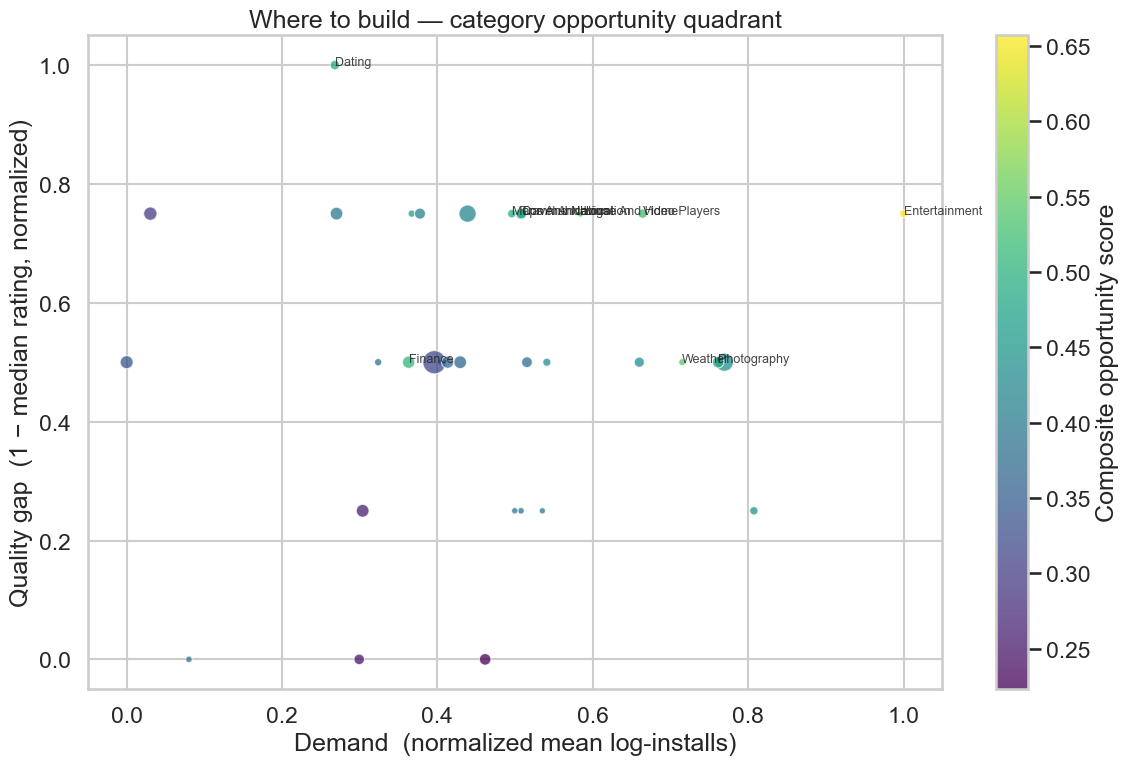

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    normalize_minmax(cat["demand"]),
    normalize_minmax(cat["quality_gap"]),
    s=cat["n_apps"].clip(lower=20) ** 0.75,
    c=cat["opportunity_default"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="white",
    linewidth=0.8,
)
for _, row in top10.iterrows():
    ax.annotate(row["category"].replace("_", " ").title(),
                (normalize_minmax(cat["demand"]).loc[row.name],
                 normalize_minmax(cat["quality_gap"]).loc[row.name]),
                fontsize=9, alpha=0.85)
ax.set_xlabel("Demand  (normalized mean log-installs)")
ax.set_ylabel("Quality gap  (1 − median rating, normalized)")
ax.set_title("Where to build — category opportunity quadrant")
cbar = plt.colorbar(sc, ax=ax, label="Composite opportunity score")
fig.tight_layout()
fig.savefig(IMAGES / "hero_quadrant.png", dpi=300)
plt.show()

## 4. Demand-side acquisition shortlist

Filter top-5 scoring categories for apps that look *well-loved and well-sized*:

- Rating ≥ 4.3
- Installs ≥ 100,000
- Reviews ≥ 5,000
- Last updated ≤ 24 months before the snapshot

Then rank by (rating × log-installs × (1 − pct_negative_reviews)).

In [7]:
top5_cats = top10.head(5)["category"].tolist()
candidates = apps[
    apps["category"].isin(top5_cats)
    & (apps["Rating"] >= 4.3)
    & (apps["installs"] >= 100_000)
    & (apps["reviews"] >= 5_000)
].copy()

snapshot = apps["last_updated"].max()
cutoff = snapshot - pd.Timedelta(days=24 * 30)
candidates = candidates[candidates["last_updated"] >= cutoff]

candidates["shortlist_score"] = (
    candidates["Rating"]
    * candidates["log_installs"]
    * (1 - candidates["pct_negative"].fillna(0.5))
)
shortlist = candidates.sort_values("shortlist_score", ascending=False).head(20)
shortlist[["App", "category", "Rating", "installs", "reviews", "price_usd", "mean_compound", "shortlist_score"]]

,App,category,Rating,installs,reviews,price_usd,mean_compound,shortlist_score
863,Credit Karma,FINANCE,4.7,10000000.0,706301,0.0,0.646006,71.426190
945,Discover Mobile,FINANCE,4.6,5000000.0,87951,0.0,0.223900,70.954764
3211,"DU Recorder – Screen Recorder, Video Editor, Live",VIDEO_PLAYERS,4.8,50000000.0,2588730,0.0,0.403614,70.421099
2892,"GO Weather - Widget, Theme, Wallpaper, Efficient",WEATHER,4.5,50000000.0,1422858,0.0,0.255255,68.895642
2871,AccuWeather: Daily Forecast & Live Weather Rep...,WEATHER,4.4,50000000.0,2053404,0.0,0.347100,68.251004
1205,Alfred Home Security Camera,HOUSE_AND_HOME,4.5,5000000.0,103305,0.0,0.428547,67.098527
2885,APE Weather ( Live Forecast),WEATHER,4.3,5000000.0,20008,0.0,0.411939,64.317362
706,H TV,ENTERTAINMENT,4.3,5000000.0,103078,0.0,0.264015,62.925880
943,Bank of America Mobile Banking,FINANCE,4.4,10000000.0,341090,0.0,0.395788,62.054669
734,Fandango Movies - Times + Tickets,ENTERTAINMENT,4.6,10000000.0,243747,0.0,0.289550,61.786034


In [8]:
shortlist.to_csv(DATA_PROCESSED / "acquisition_shortlist.csv", index=False)
print(f"Shortlist saved: {DATA_PROCESSED / 'acquisition_shortlist.csv'}")

Shortlist saved: /Users/moham1/Desktop/data-analyst-portfolio/.claude/worktrees/trusting-buck/01_subscription_apps_intelligence/data/processed/acquisition_shortlist.csv


## 5. Export Power BI data model

Dense, denormalized table with readable column names. The Power BI build guide (`dashboard/powerbi_build_guide.md`) consumes this file.

In [9]:
pbi = apps.rename(columns={
    "App": "App Name",
    "category": "Category",
    "Rating": "Rating",
    "reviews": "Review Count",
    "installs": "Installs",
    "size_mb": "Size (MB)",
    "price_usd": "Price (USD)",
    "is_paid": "Is Paid",
    "price_band": "Price Band",
    "last_updated": "Last Updated",
    "age_days": "Age (Days)",
    "mean_compound": "Sentiment Compound",
    "pct_negative": "Pct Negative Reviews",
})
pbi_cols = [
    "App Name", "Category", "Rating", "Review Count", "Installs", "Size (MB)",
    "Price (USD)", "Is Paid", "Price Band", "Last Updated", "Age (Days)",
    "Sentiment Compound", "Pct Negative Reviews",
]
pbi = pbi[pbi_cols]
pbi.to_csv(DATA_PROCESSED / "powerbi_model.csv", index=False)
print(f"Power BI model: {pbi.shape} -> {DATA_PROCESSED / 'powerbi_model.csv'}")
pbi.head()

Power BI model: (9659, 16) -> /Users/moham1/Desktop/data-analyst-portfolio/.claude/worktrees/trusting-buck/01_subscription_apps_intelligence/data/processed/powerbi_model.csv


,App Name,Category,Category,Rating,Review Count,Installs,Installs,Size (MB),Price (USD),Is Paid,Price Band,Last Updated,Last Updated,Age (Days),Sentiment Compound,Pct Negative Reviews
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,ART_AND_DESIGN,4.1,159,"10,000+",10000.0,19.0,0.0,0,Free,"January 7, 2018",2018-01-07,213,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,ART_AND_DESIGN,3.9,967,"500,000+",500000.0,14.0,0.0,0,Free,"January 15, 2018",2018-01-15,205,0.201477,0.181818
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,ART_AND_DESIGN,4.7,87510,"5,000,000+",5000000.0,8.7,0.0,0,Free,"August 1, 2018",2018-08-01,7,NaN,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,ART_AND_DESIGN,4.5,215644,"50,000,000+",50000000.0,25.0,0.0,0,Free,"June 8, 2018",2018-06-08,61,NaN,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,ART_AND_DESIGN,4.3,967,"100,000+",100000.0,2.8,0.0,0,Free,"June 20, 2018",2018-06-20,49,NaN,NaN


## Takeaways (where to build)

- The opportunity ranking is **stable** across the three weight schemes (Kendall τ values printed above) — the top-5 categories survive plausible re-weighting.
- The quadrant chart (hero image) places categories on *demand × quality gap*; the upper-right is where an operator should prefer to enter.
- The shortlist is a **demand-side** starting point, not a financial screen. Any actual acquisition decision needs revenue and DAU data Google Play does not provide.